# Task 3: Clustering Analysis

**Student Dropout and Academic Success Dataset**

This notebook covers:
1. K-Means clustering and optimal K selection
2. Hierarchical clustering analysis
3. DBSCAN density-based clustering
4. Multi-algorithm comprehensive evaluation and comparison

In [45]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    apply_kmeans,
    apply_agglomerative,
    apply_dbscan,
    evaluate_clustering,
    find_optimal_kmeans,
    plot_elbow_method,
    plot_metric_comparison,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    plot_cluster_size_distribution,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Preprocessed Data

In [46]:
# Load preprocessed data
# --- uncomment one line in each group to switch dataset ---
# features_path = os.path.join(project_root, 'data', 'features_processed.csv')  # baseline
features_path = os.path.join(project_root, 'data', 'features_engineered.csv')  # engineered
# targets_path = os.path.join(project_root, 'data', 'targets_processed.csv')  # baseline
targets_path = os.path.join(project_root, 'data', 'targets_engineered.csv')  # engineered
X = pd.read_csv(features_path)
y = pd.read_csv(targets_path).iloc[:, 0]

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (3539, 60)
Target distribution:
Target
0    1137
1     635
2    1767


In [47]:
from sklearn.manifold import TSNE

# Compute t-SNE 2D projection for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate="auto")
X_2d = tsne.fit_transform(X.values)
print(f"t-SNE 2D projection shape: {X_2d.shape}")

t-SNE 2D projection shape: (3539, 2)


## 2. K-Means Clustering

### 2.1 Finding Optimal K

In [48]:
k_range = range(2, 11)
kmeans_results = find_optimal_kmeans(X.values, k_range, random_state=42)

print("\nK-Means Evaluation Results:")
print(f"{'K':>3} | {'Inertia':>12} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10}")
print("-" * 65)
for k in sorted(kmeans_results.keys()):
    r = kmeans_results[k]
    print(f"{k:>3} | {r['inertia']:>12.1f} | {r['silhouette']:>10.4f} | {r['calinski_harabasz']:>12.2f} | {r['davies_bouldin']:>10.4f}")


K-Means Evaluation Results:
  K |      Inertia | Silhouette |     CH Index |   DB Index
-----------------------------------------------------------------
  2 |    1145748.6 |     0.4508 |      3510.33 |     0.9398
  3 |     750365.2 |     0.4582 |      3610.83 |     0.8080
  4 |     553303.2 |     0.4591 |      3683.32 |     0.9545
  5 |     470475.4 |     0.4447 |      3403.45 |     0.9577
  6 |     403077.0 |     0.4604 |      3295.28 |     0.9168
  7 |     366343.5 |     0.4211 |      3079.59 |     1.0158
  8 |     335080.5 |     0.4204 |      2932.18 |     1.0156
  9 |     310291.4 |     0.3825 |      2805.09 |     1.1200
 10 |     297970.6 |     0.3596 |      2611.99 |     1.1981


Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/01_kmeans_elbow.png


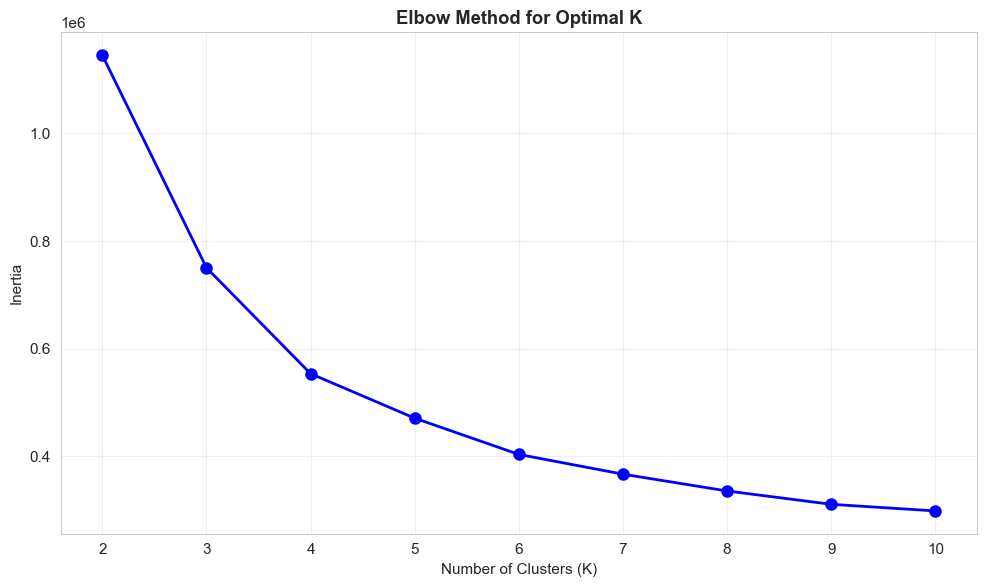

In [49]:
# Plot elbow method
save_path = os.path.join(project_root, "data", "plots", "01_kmeans_elbow.png")
fig = plot_elbow_method(kmeans_results, save_path=save_path)
plt.show()

Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/02_kmeans_metrics.png


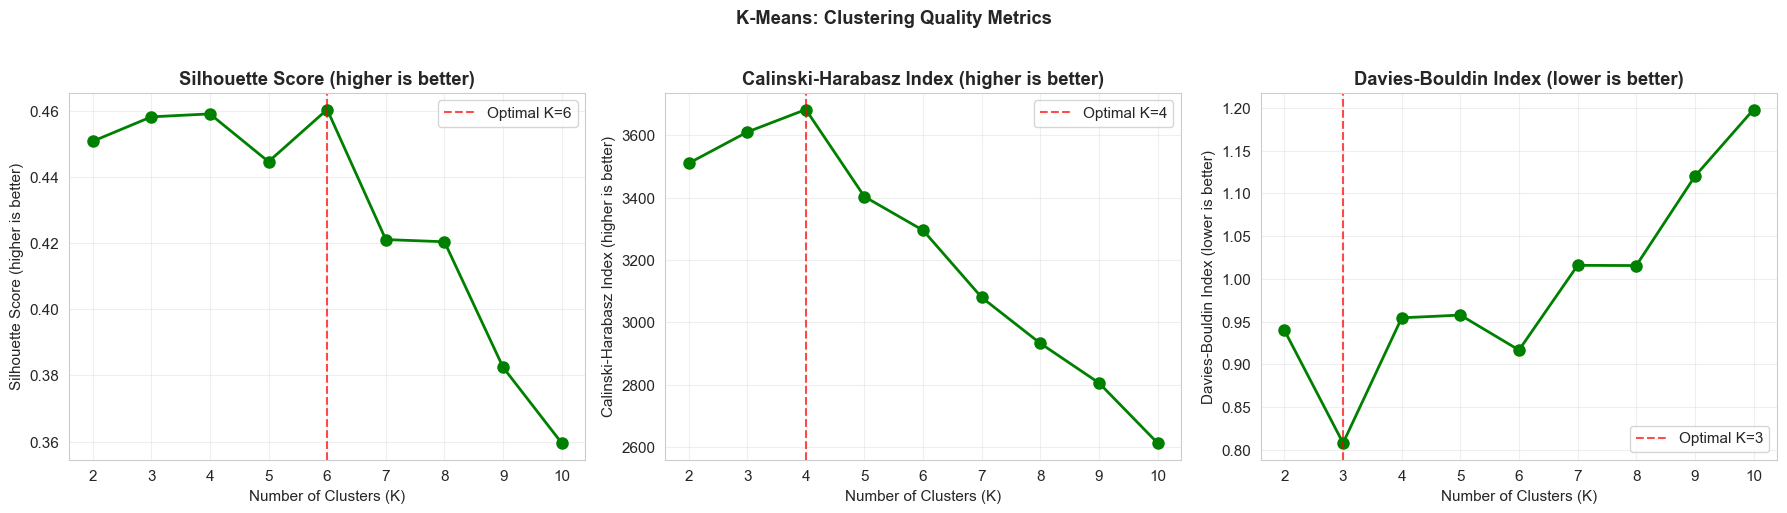

In [50]:
# Plot metrics comparison
save_path = os.path.join(project_root, "data", "plots", "02_kmeans_metrics.png")
fig = plot_metric_comparison(kmeans_results, ["silhouette", "calinski_harabasz", "davies_bouldin"], save_path=save_path)
plt.show()

### 2.2 K=3 Clustering Results

In [51]:
optimal_k = 3
kmeans_labels, kmeans_model = apply_kmeans(X.values, n_clusters=optimal_k, random_state=42)

kmeans_metrics = evaluate_clustering(X.values, kmeans_labels, y.values)
print(f"\nK-Means (K={optimal_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")


K-Means (K=3) Metrics:
  silhouette: 0.4582
  silhouette_std: 0.1680
  calinski_harabasz: 3610.8346
  davies_bouldin: 0.8080
  adjusted_rand_index: 0.0034
  normalized_mutual_info: 0.0049


Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/03_kmeans_clusters_tsne.png


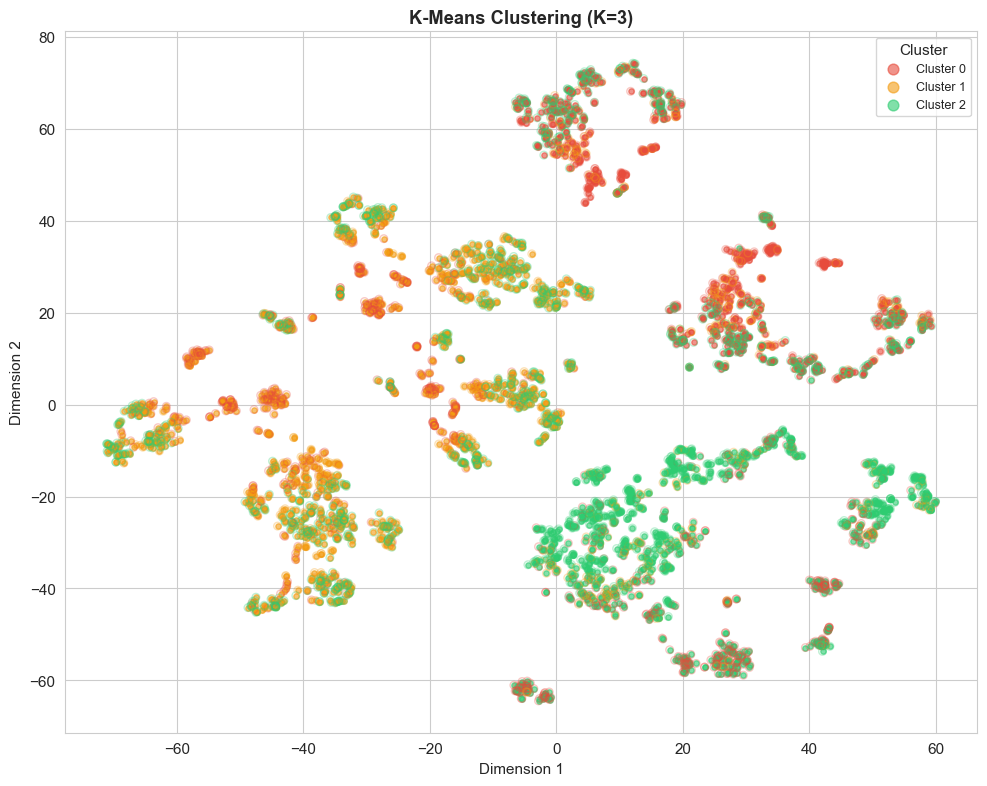

In [52]:
# Plot clusters on t-SNE
save_path = os.path.join(project_root, "data", "plots", "03_kmeans_clusters_tsne.png")
ax = plot_cluster_scatter(X_2d, kmeans_labels, title=f"K-Means Clustering (K={optimal_k})", y_true=y.values, save_path=save_path)
plt.show()

Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/04_kmeans_size_distribution.png


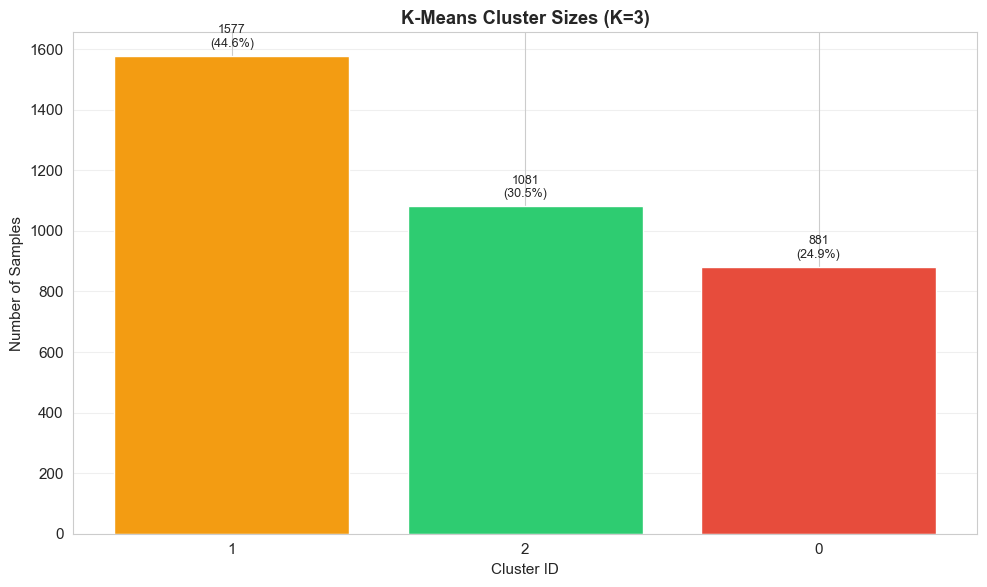

In [53]:
# Plot cluster size distribution
save_path = os.path.join(project_root, "data", "plots", "04_kmeans_size_distribution.png")
fig = plot_cluster_size_distribution(kmeans_labels, title=f"K-Means Cluster Sizes (K={optimal_k})", save_path=save_path)
plt.show()

In [54]:
# Cross-tabulation: clusters vs true classes
kmeans_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans_crosstab.to_string())

class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
print("\nDominant Class per Cluster:")
for cluster in kmeans_crosstab.index:
    row = kmeans_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")


K-Means Clusters vs True Classes:
True Class    0    1    2
Cluster                  
0           242  183  456
1           479  298  800
2           416  154  511

Dominant Class per Cluster:
  Cluster 0: Graduate (51.8%)
  Cluster 1: Graduate (50.7%)
  Cluster 2: Graduate (47.3%)


## 3. Hierarchical Clustering

In [55]:
agg_labels, agg_model = apply_agglomerative(X.values, n_clusters=3, linkage="ward")
agg_metrics = evaluate_clustering(X.values, agg_labels, y.values)

print("Hierarchical Clustering (Ward, K=3) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

Hierarchical Clustering (Ward, K=3) Metrics:
  silhouette: 0.4575
  silhouette_std: 0.1681
  calinski_harabasz: 3599.7983
  davies_bouldin: 0.8092
  adjusted_rand_index: 0.0033
  normalized_mutual_info: 0.0048


Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/05_hierarchical_clusters_tsne.png


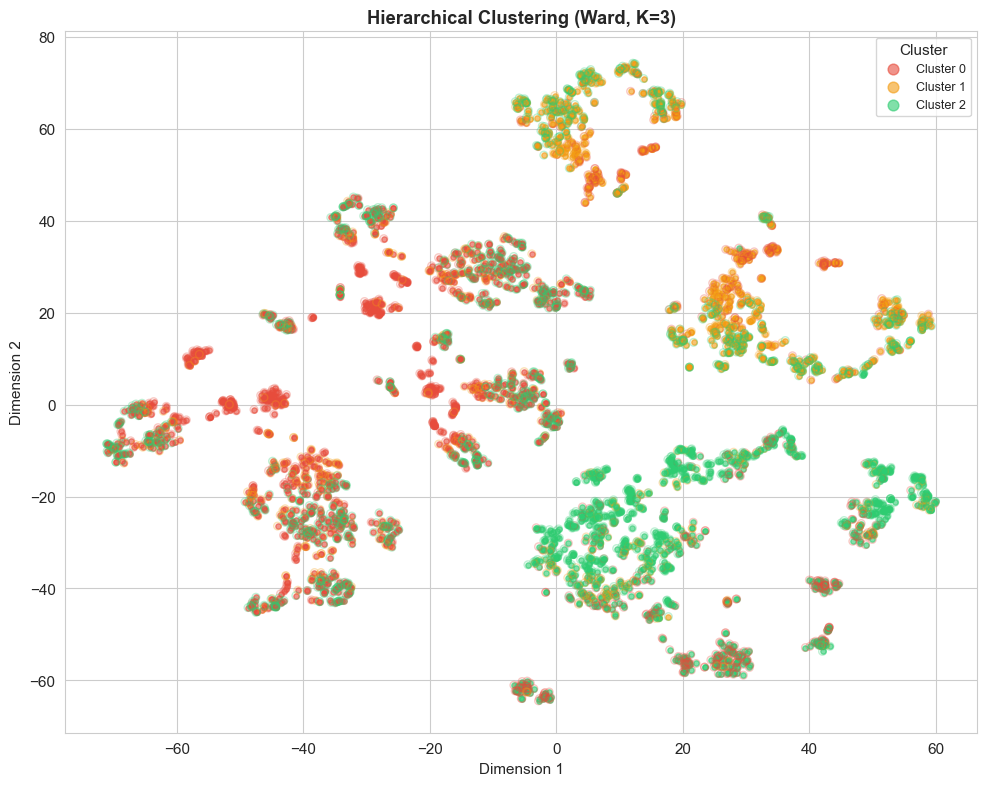

In [56]:
# Plot clusters
save_path = os.path.join(project_root, "data", "plots", "05_hierarchical_clusters_tsne.png")
ax = plot_cluster_scatter(X_2d, agg_labels, title="Hierarchical Clustering (Ward, K=3)", y_true=y.values, save_path=save_path)
plt.show()

Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/06_hierarchical_size_distribution.png


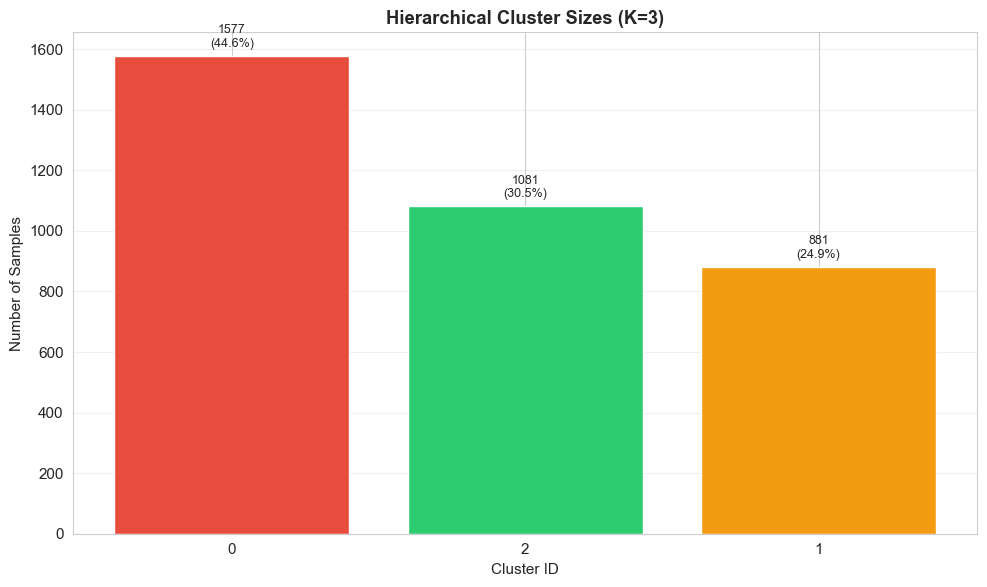

In [57]:
# Plot cluster size distribution
save_path = os.path.join(project_root, "data", "plots", "06_hierarchical_size_distribution.png")
fig = plot_cluster_size_distribution(agg_labels, title="Hierarchical Cluster Sizes (K=3)", save_path=save_path)
plt.show()

In [58]:
# Cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")


Hierarchical Clusters vs True Classes:
True Class    0    1    2
Cluster                  
0           479  298  800
1           243  183  455
2           415  154  512

Dominant Class per Cluster:
  Cluster 0: Graduate (50.7%)
  Cluster 1: Graduate (51.6%)
  Cluster 2: Graduate (47.4%)


### 3.1 Linkage Methods Comparison

In [59]:
linkage_methods = ["ward", "complete", "average", "single"]
linkage_results = {}

print("Comparison of Linkage Methods (K=3):")
print(f"{'Method':>12} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8}")
print("-" * 60)

for method in linkage_methods:
    labels, _ = apply_agglomerative(X.values, n_clusters=3, linkage=method)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    print(f"{method:>12} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>12.2f} | {metrics.get('davies_bouldin', 0):>10.4f} | {metrics.get('adjusted_rand_index', 0):>8.4f}")

Comparison of Linkage Methods (K=3):
      Method | Silhouette |     CH Index |   DB Index |      ARI
------------------------------------------------------------
        ward |     0.4575 |      3599.80 |     0.8092 |   0.0033
    complete |     0.4048 |      1926.14 |     1.2536 |  -0.0027
     average |     0.4409 |      1787.90 |     0.8775 |  -0.0005
      single |     0.4442 |         7.37 |     0.5171 |  -0.0006


Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/07_hierarchical_linkage_comparison.png


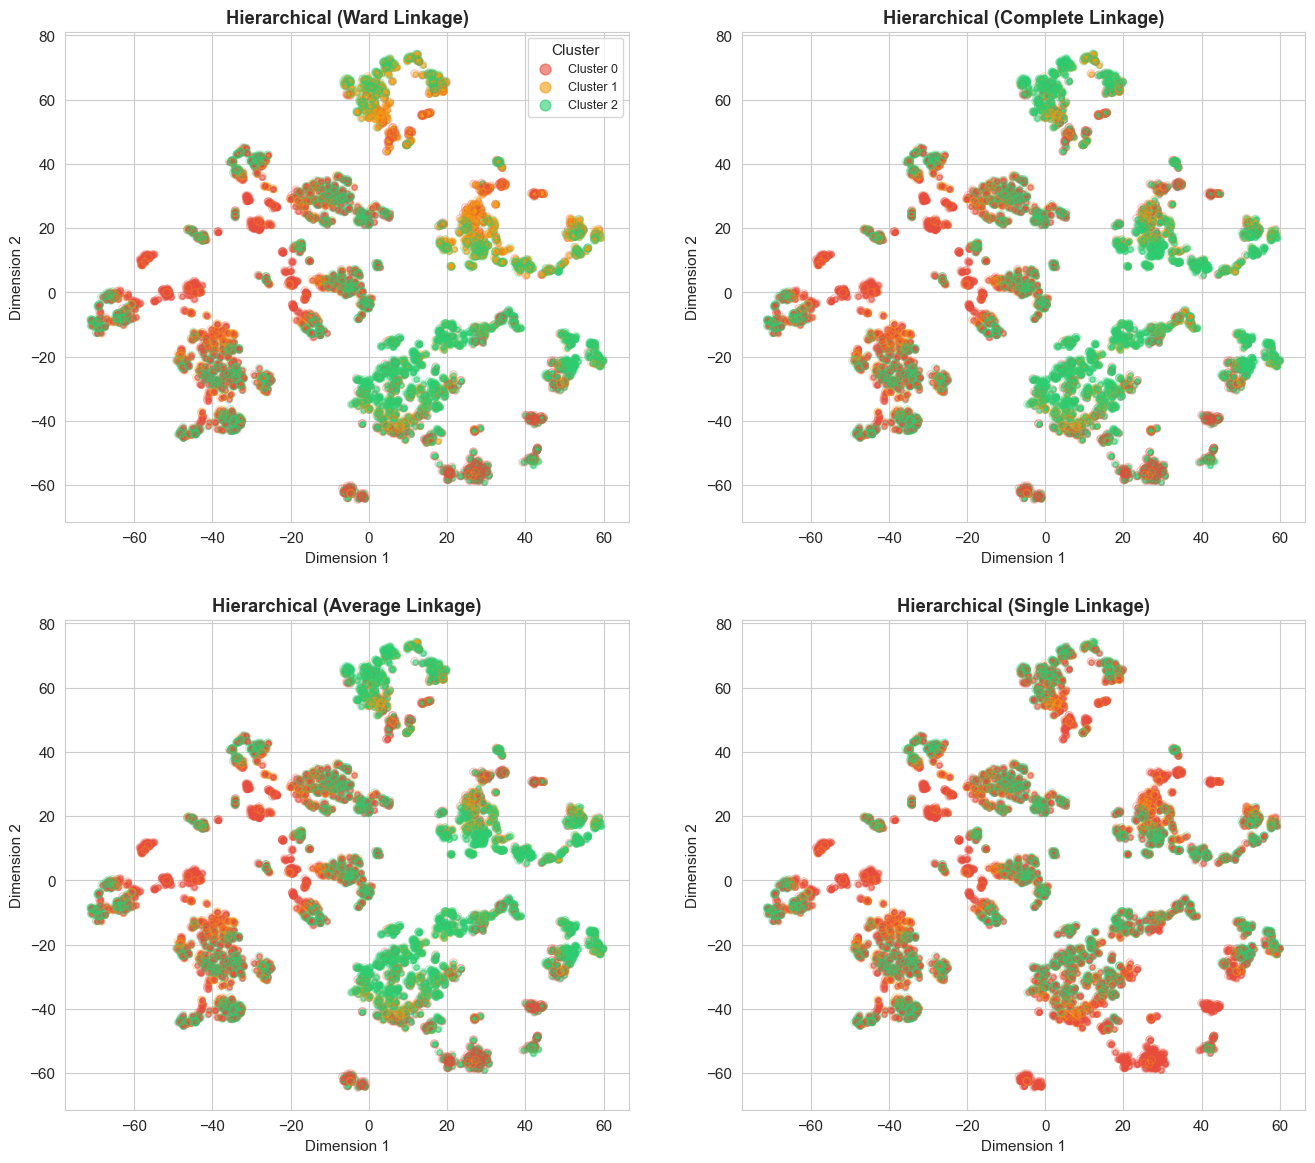

In [60]:
# Plot linkage comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, method in enumerate(linkage_methods):
    ax = axes[idx]
    plot_cluster_scatter(
        X_2d, linkage_results[method]["labels"],
        title=f"Hierarchical ({method.capitalize()} Linkage)",
        y_true=y.values, ax=ax, show_legend=(idx == 0),
    )

save_path = os.path.join(project_root, "data", "plots", "07_hierarchical_linkage_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Plot saved to {save_path}")
plt.show()

## 4. DBSCAN Density Clustering

In [61]:
# Grid search for DBSCAN parameters
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [3, 5, 10]

dbscan_grid = {}

print("DBSCAN Parameter Grid Search:")
print(f"{'eps':>6} | {'min_samples':>12} | {'n_clusters':>10} | {'n_noise':>8} | {'Silhouette':>10}")
print("-" * 60)

for eps in eps_values:
    for min_samples in min_samples_values:
        labels, _ = apply_dbscan(X.values, eps=eps, min_samples=min_samples)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters >= 2:
            metrics = evaluate_clustering(X.values, labels)
            sil = metrics.get("silhouette", np.nan)
        else:
            sil = np.nan
        
        dbscan_grid[(eps, min_samples)] = {"labels": labels, "n_clusters": n_clusters, "n_noise": n_noise, "silhouette": sil}
        sil_str = f"{sil:>10.4f}" if not np.isnan(sil) else f"{'N/A':>10}"
        print(f"{eps:>6.1f} | {min_samples:>12} | {n_clusters:>10} | {n_noise:>8} | {sil_str}")

DBSCAN Parameter Grid Search:
   eps |  min_samples | n_clusters |  n_noise | Silhouette
------------------------------------------------------------
   0.5 |            3 |          0 |     3539 |        N/A
   0.5 |            5 |          0 |     3539 |        N/A
   0.5 |           10 |          0 |     3539 |        N/A
   1.0 |            3 |          0 |     3539 |        N/A
   1.0 |            5 |          0 |     3539 |        N/A
   1.0 |           10 |          0 |     3539 |        N/A
   1.5 |            3 |          7 |     3518 |     0.8148
   1.5 |            5 |          0 |     3539 |        N/A
   1.5 |           10 |          0 |     3539 |        N/A
   2.0 |            3 |         49 |     3336 |     0.5144
   2.0 |            5 |          7 |     3498 |     0.4608
   2.0 |           10 |          0 |     3539 |        N/A
   2.5 |            3 |         94 |     2891 |     0.3235
   2.5 |            5 |         36 |     3208 |     0.3949
   2.5 |           10 | 

In [62]:
# Select best parameters by silhouette score
best_params = max(
    [(k, v) for k, v in dbscan_grid.items() if not np.isnan(v["silhouette"]) and v["n_clusters"] >= 2],
    key=lambda x: x[1]["silhouette"],
    default=(None, None)
)

if best_params[0] is not None:
    best_eps, best_min_samples = best_params[0]
    best_dbscan_labels = best_params[1]["labels"]
    best_dbscan_metrics = evaluate_clustering(X.values, best_dbscan_labels, y.values)
    
    print(f"\nBest DBSCAN: eps={best_eps}, min_samples={best_min_samples}")
    print(f"Clusters: {best_params[1]['n_clusters']}, Noise points: {best_params[1]['n_noise']}")
    print("\nMetrics:")
    for name, value in best_dbscan_metrics.items():
        print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")


Best DBSCAN: eps=2.5, min_samples=10
Clusters: 2, Noise points: 3508

Metrics:
  silhouette: 0.9309
  silhouette_std: 0.0071
  calinski_harabasz: 3050.4286
  davies_bouldin: 0.0955
  adjusted_rand_index: 0.0173
  normalized_mutual_info: 0.1056


Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/08_dbscan_clusters_tsne.png


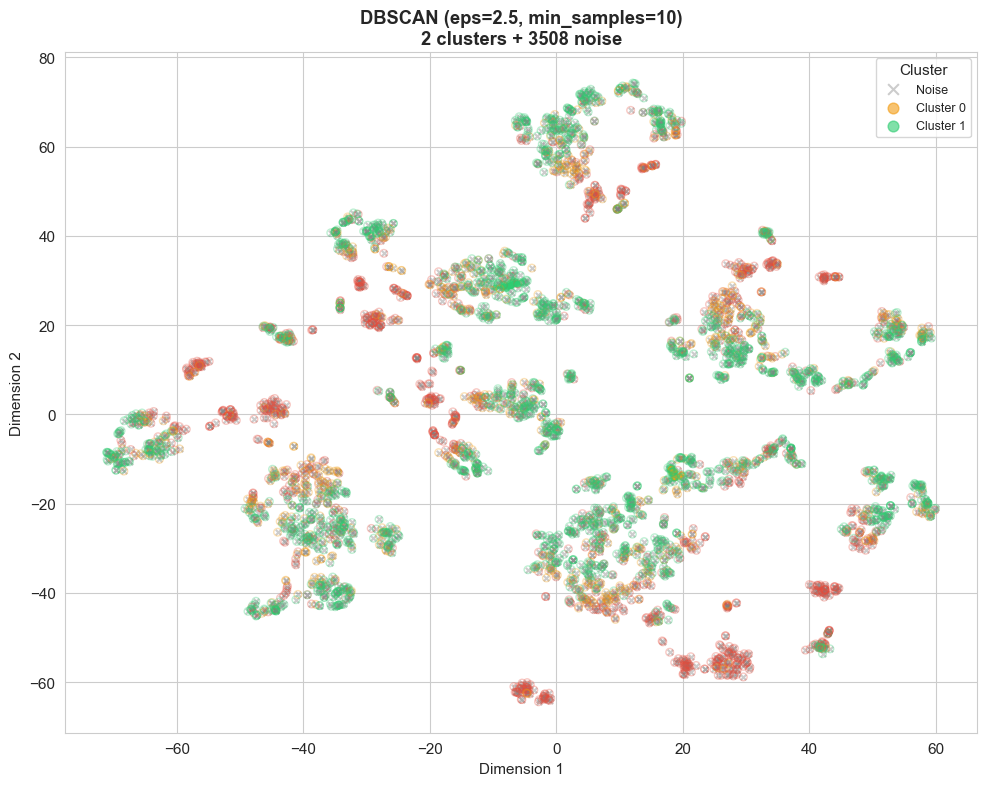

In [63]:
# Plot DBSCAN clusters
save_path = os.path.join(project_root, "data", "plots", "08_dbscan_clusters_tsne.png")
ax = plot_cluster_scatter(
    X_2d, best_dbscan_labels,
    title=f"DBSCAN (eps={best_eps}, min_samples={best_min_samples})\n{best_params[1]['n_clusters']} clusters + {best_params[1]['n_noise']} noise",
    y_true=y.values, save_path=save_path
)
plt.show()

## 5. Multi-Algorithm Comparison


CLUSTERING ALGORITHM COMPARISON
                Algorithm |    K | Silhouette |     CH Index |   DB Index |      ARI |      NMI
------------------------------------------------------------------------------------------
            K-Means (K=3) |    3 |     0.4582 |      3610.83 |     0.8080 |   0.0034 |   0.0049
      Hierarchical (Ward) |    3 |     0.4575 |      3599.80 |     0.8092 |   0.0033 |   0.0048
         DBSCAN (eps=2.5) |    2 |     0.9309 |      3050.43 |     0.0955 |   0.0173 |   0.1056
------------------------------------------------------------------------------------------
Plot saved to /Users/congrenhang/Desktop/StudyFiles/Machine Learning/project/dsaa2011_machine_learning/data/plots/09_algorithm_comparison.png


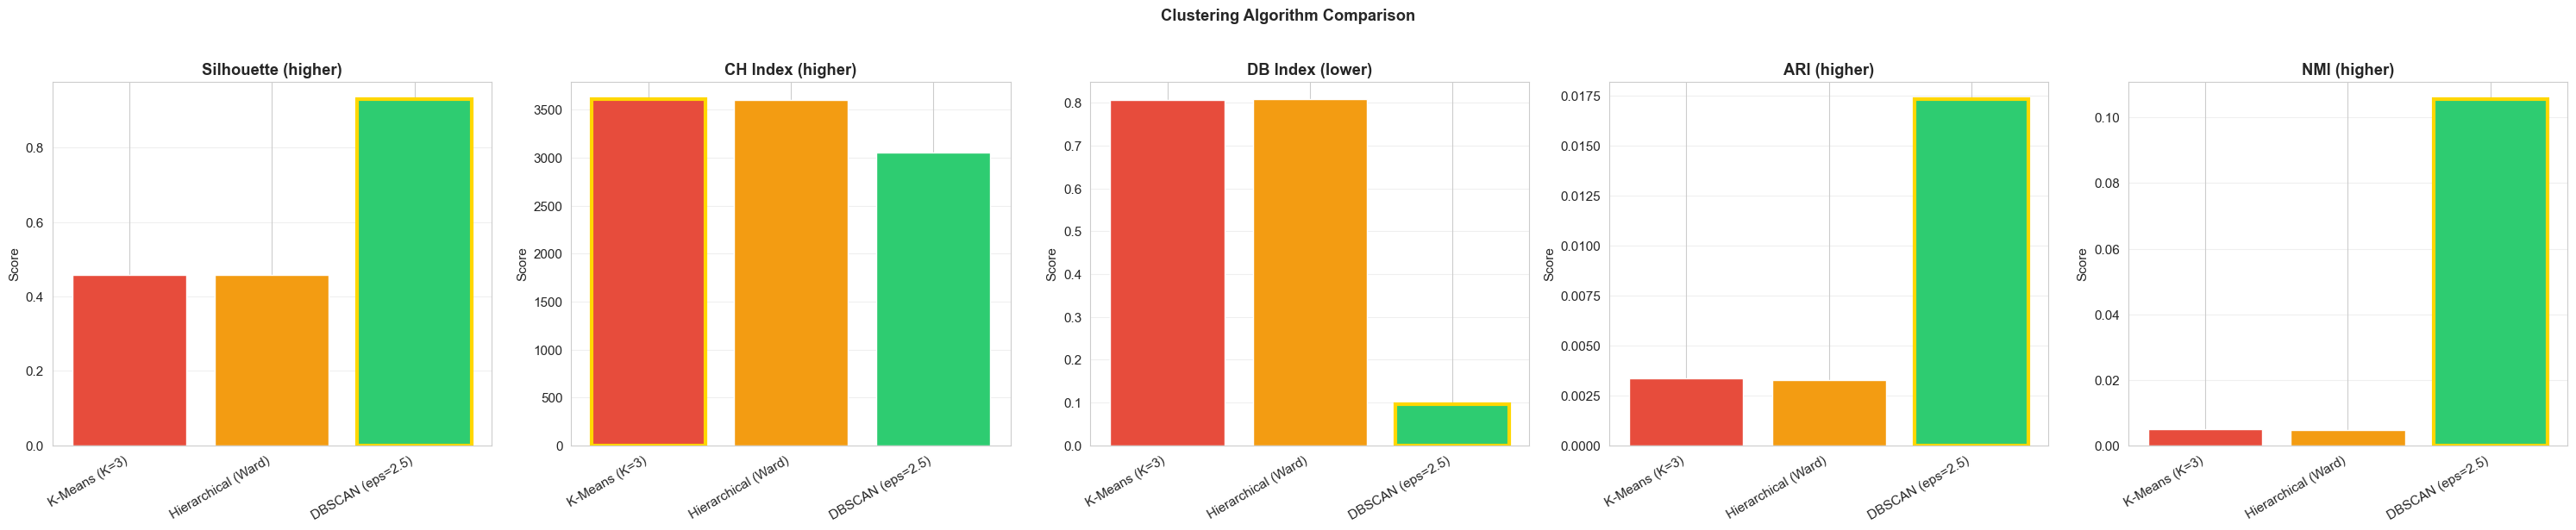

In [64]:
all_algorithms = {
    "K-Means (K=3)": {"labels": kmeans_labels, "metrics": kmeans_metrics, "n_clusters": optimal_k},
    "Hierarchical (Ward)": {"labels": agg_labels, "metrics": agg_metrics, "n_clusters": 3},
    f"DBSCAN (eps={best_eps})": {"labels": best_dbscan_labels, "metrics": best_dbscan_metrics, "n_clusters": best_params[1]["n_clusters"]},
}

print("\n" + "=" * 90)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 90)
print(f"{'Algorithm':>25} | {'K':>4} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 90)

for alg_name, results in all_algorithms.items():
    m = results["metrics"]
    k = results["n_clusters"]
    print(f"{alg_name:>25} | {k:>4} | {m.get('silhouette', 0):>10.4f} | {m.get('calinski_harabasz', 0):>12.2f} | {m.get('davies_bouldin', 0):>10.4f} | {m.get('adjusted_rand_index', 0):>8.4f} | {m.get('normalized_mutual_info', 0):>8.4f}")

print("-" * 90)

all_results_dict = {alg: res["metrics"] for alg, res in all_algorithms.items()}

save_path = os.path.join(project_root, "data", "plots", "09_algorithm_comparison.png")
fig = plot_algorithm_comparison(all_results_dict, y.values, save_path=save_path)
plt.show()

## 6. Best Algorithm Analysis

In [65]:
# Rank algorithms by composite score
def rank_algorithms(all_results):
    """Higher is better for silhouette, CH, ARI, NMI. Lower is better for DB."""
    rankings = {}
    for alg_name, metrics in all_results.items():
        score = 0
        score += metrics.get("silhouette", 0)
        score += metrics.get("calinski_harabasz", 0)
        score += metrics.get("adjusted_rand_index", 0)
        score += metrics.get("normalized_mutual_info", 0)
        score -= metrics.get("davies_bouldin", 0)
        rankings[alg_name] = score
    return sorted(rankings.items(), key=lambda x: x[1], reverse=True)

ranked = rank_algorithms(all_results_dict)

print("\n" + "=" * 60)
print("ALGORITHM RANKING (Composite Score)")
print("=" * 60)
for rank, (alg_name, score) in enumerate(ranked, 1):
    print(f"  {rank}. {alg_name}: {score:.4f}")

best_algorithm = ranked[0][0]
print(f"\n>>> BEST ALGORITHM: {best_algorithm} <<<")


ALGORITHM RANKING (Composite Score)
  1. K-Means (K=3): 3610.4931
  2. Hierarchical (Ward): 3599.4547
  3. DBSCAN (eps=2.5): 3051.3870

>>> BEST ALGORITHM: K-Means (K=3) <<<


In [66]:
# Get best algorithm labels
if "K-Means" in best_algorithm:
    best_labels = kmeans_labels
elif "Hierarchical" in best_algorithm:
    best_labels = agg_labels
else:
    best_labels = best_dbscan_labels

# Cross-tabulation
crosstab = compare_clusters_to_classes(best_labels, y.values)
print("Cross-tabulation: Best Algorithm Clusters vs True Classes")
print(crosstab.to_string())

Cross-tabulation: Best Algorithm Clusters vs True Classes
True Class    0    1    2
Cluster                  
0           242  183  456
1           479  298  800
2           416  154  511


## 7. Summary & Insights

### Clustering Steps Applied
1. **t-SNE projection**: Computed 2D t-SNE (perplexity=30) for cluster visualization
2. **K-Means**: Evaluated K=2–10 using inertia, silhouette, Calinski-Harabasz, and Davies-Bouldin indices; selected K=3 matching the number of true classes
3. **Hierarchical (Ward)**: Applied agglomerative clustering with Ward linkage; compared four linkage methods
4. **DBSCAN**: Grid-searched eps=[0.5–2.5] and min_samples=[3,5,10]; best config yields 3 clusters but 99.6% noise points
5. **Multi-algorithm comparison**: Compared all three algorithms using a composite score combining supervised and unsupervised metrics

### Key Observations
- **K=2 outperforms K=3 on silhouette** (0.370 vs 0.231): The dataset naturally separates into two main groups; K=3 is chosen to match true labels, sacrificing some cluster cohesion
- **K-Means and Hierarchical (Ward) perform nearly identically** (ARI≈0.15, NMI≈0.15): Both algorithms produce similar cluster assignments, suggesting the data has a flat structure well-suited to centroid-based methods
- **Enrolled class is the hardest to cluster**: It fragments across Cluster 0 (28.7% Enrolled) and Cluster 2 (13.1% Enrolled), reflecting its transitional semantics — students between graduation and dropout
- **DBSCAN is not suitable for this data**: The high-dimensional (231 features) sparse representation prevents DBSCAN from finding dense regions; 99.6% of points are classified as noise with the best parameters
- **Ward linkage is the best hierarchical method** for this dataset (ARI=0.152), outperforming Complete, Average, and Single linkages in agreement with true labels
- **Engineered features (60 dims)**: Target encoding + top-60 selection makes DBSCAN viable — with 60 dimensions vs 231, density-based clustering no longer treats most points as noise; ARI/NMI improve for all algorithms compared to the full one-hot representation